In [1]:
import pandas as pd
import plotly.express as px

In [2]:
f = '../data/innovacion_indice/conjunto_de_datos/rank_ino.csv'
innovacion_rank = pd.read_csv(f, usecols=[0,1,2,3], na_values=['ND', 'NAN'])

In [3]:
innovacion_rank = innovacion_rank.sort_values(by=["Year", "Score"], ascending=[True, True])

In [7]:
innovacion_rank

,Economies,Year,Score,Rank
24,Angola,2011,0.0,0
120,Barbados,2011,0.0,0
132,Bielorrusia,2011,0.0,0
156,Belice,2011,0.0,0
180,Bután,2011,0.0,0
...,...,...,...,...
1163,Países Bajos,2022,58.0,5
1691,Reino Unido,2022,59.7,4
1523,Suecia,2022,61.6,3
1703,Estados Unidos,2022,61.8,2


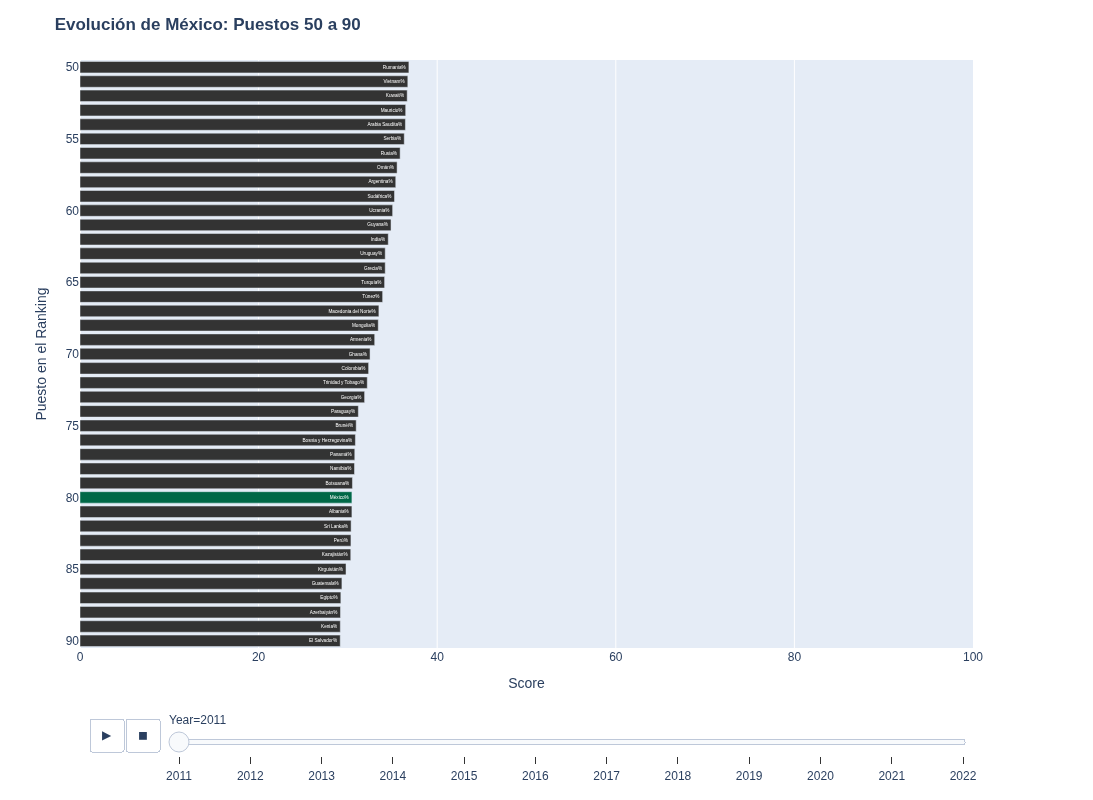

In [5]:
df = innovacion_rank.copy()
df['Score'] = pd.to_numeric(df['Score'], errors='coerce').fillna(0)

df_filtered_list = []

for year in sorted(df['Year'].unique()):
    df_year = df[df['Year'] == year].sort_values(by='Score', ascending=False).reset_index(drop=True)
    df_year['Rank_Display'] = range(1, len(df_year) + 1)
    window = df_year[(df_year['Rank_Display'] >= 45) & (df_year['Rank_Display'] <= 95)].copy()    
    window['Color_Group'] = window['Economies'].apply(lambda x: 'México' if x == 'México' else 'Otros')
    df_filtered_list.append(window)

df_final = pd.concat(df_filtered_list)


fig = px.bar(
    df_final,
    x="Score",
    y="Rank_Display",
    text="Economies",
    animation_frame="Year",
    animation_group="Economies",
    orientation='h',
    color="Color_Group",
    color_discrete_map={'México': '#006847', 'Otros': '#333333'},
    range_x=[0, 100],
    range_y=[90.5, 49.5], 
    height=800
)

fig.update_layout(
    yaxis=dict(
        title="Puesto en el Ranking",
        tickmode='linear',
        dtick=5 
    ),
    showlegend=False,
    title="<b>Evolución de México: Puestos 50 a 90</b>",
    margin=dict(r=120)
)

fig.update_traces(
    texttemplate='%{text}%', 
    textposition='inside',
    cliponaxis=False
)

fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 1200
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 900

fig.show()